# 🎓 Dự Đoán Trầm Cảm Sinh Viên Dựa Trên Áp Lực Học Tập, Giờ Ngủ & Lối Sống
## Khai Phá Dữ Liệu — Project Cuối Kỳ

---

| | |
|---|---|
| **Đề tài** | Dựa vào áp lực học tập, giờ ngủ, stress tài chính và lối sống, sinh viên có bị trầm cảm không? |
| **Dataset** | [Student Depression Dataset](https://www.kaggle.com/datasets/hopesb/student-depression-dataset/data) — Kaggle |
| **Loại bài toán** | Binary Classification |
| **Biến mục tiêu** | `Depression` (1 = có trầm cảm, 0 = không) |
| **Số mẫu** | 27,901 sinh viên |
| **Thuật toán** | Logistic Regression · Decision Tree · Random Forest · XGBoost |

## 0. Cài đặt thư viện

In [ ]:
# Bỏ comment nếu chưa cài
# !pip install notebook ipykernel pandas numpy scikit-learn matplotlib seaborn xgboost

## 1. Import thư viện & Cấu hình

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection  import (train_test_split)
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Hằng số ──────────────────────────────────────────────────────────────────
DATA_PATH    = './data/Student_Depression_Dataset.csv'
RANDOM_STATE = 42
TARGET_COL   = 'Depression'
COLORS       = {'green': '#4CAF50', 'red': '#F44336',
                'blue': '#2196F3', 'orange': '#FF9800', 'purple': '#9C27B0'}

print("✅ Import hoàn tất!")

✅ Import hoàn tất!


## 2. Tải dữ liệu

In [ ]:
df = pd.read_csv(DATA_PATH)

## 3. Tiền xử lý dữ liệu

In [ ]:
df_clean = df.copy()

# ── 1. Xử lý missing values ───────────────────────────────────────────────────
n_missing = df_clean.isnull().sum().sum()
if n_missing > 0:
    # Số: điền median; Categorical: điền mode
    num_feats = df_clean.select_dtypes(include=np.number).columns.tolist()
    cat_feats  = df_clean.select_dtypes(include='object').columns.tolist()
    for c in num_feats:
        df_clean[c].fillna(df_clean[c].median(), inplace=True)
    for c in cat_feats:
        df_clean[c].fillna(df_clean[c].mode()[0], inplace=True)
    print(f"✅ Đã xử lý {n_missing} missing values")
else:
    print("✅ Không có missing values")

# ── 2. Mã hóa Sleep Duration (ordinal — có thứ tự) ───────────────────────────
sleep_map = {
    'Less than 5 hours': 1,
    '5-6 hours': 2,
    '7-8 hours': 3,
    'More than 8 hours': 4
}
df_clean['Sleep Duration Enc'] = df_clean['Sleep Duration'].map(sleep_map).fillna(2)
print(f"✅ Mã hóa Sleep Duration (ordinal): {sleep_map}")

# ── 3. Mã hóa Dietary Habits (ordinal) ───────────────────────────────────────
diet_map = {'Unhealthy': 1, 'Moderate': 2, 'Healthy': 3}
df_clean['Dietary Habits Enc'] = df_clean['Dietary Habits'].map(diet_map).fillna(2)
print(f"✅ Mã hóa Dietary Habits (ordinal):   {diet_map}")

# ── 4. Mã hóa binary ─────────────────────────────────────────────────────────
binary_cols = {
    'Gender':                               {'Male': 0, 'Female': 1},
    'Have you ever had suicidal thoughts ?':{'No': 0, 'Yes': 1},
    'Family History of Mental Illness':     {'No': 0, 'Yes': 1},
}
for col, mapping in binary_cols.items():
    df_clean[col + ' Enc'] = df_clean[col].map(mapping)
    print(f"✅ Mã hóa {col}: {mapping}")

# ── 5. Mã hóa nominal còn lại (City, Degree, Profession) ─────────────────────
nominal_cols = ['City', 'Degree', 'Profession']
le_dict = {}
for c in nominal_cols:
    le = LabelEncoder()
    df_clean[c + ' Enc'] = le.fit_transform(df_clean[c].astype(str))
    le_dict[c] = le
    print(f"✅ LabelEncoder {c}: {len(le.classes_)} nhãn")

# ── 6. Định nghĩa feature set ────────────────────────────────────────────────
FEATURES = [
    # Biến số gốc
    'Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
    'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress',
    # Biến đã mã hóa
    'Sleep Duration Enc', 'Dietary Habits Enc',
    'Gender Enc',
    'Have you ever had suicidal thoughts ? Enc',
    'Family History of Mental Illness Enc',
    'City Enc', 'Degree Enc', 'Profession Enc'
]

X = df_clean[FEATURES]
X = X.apply(lambda col: col.fillna(col.mode()[0]) if not col.mode().empty else col)
y = df_clean[TARGET_COL]
print(f"✅ Feature set: {len(FEATURES)} features")
print(f"   Shape X: {X.shape} | Shape y: {y.shape}")
print(f"   Target: 0={( y==0).sum():,}  1={(y==1).sum():,}")

✅ Đã xử lý 3 missing values
✅ Mã hóa Sleep Duration (ordinal): {'Less than 5 hours': 1, '5-6 hours': 2, '7-8 hours': 3, 'More than 8 hours': 4}
✅ Mã hóa Dietary Habits (ordinal):   {'Unhealthy': 1, 'Moderate': 2, 'Healthy': 3}
✅ Mã hóa Gender: {'Male': 0, 'Female': 1}
✅ Mã hóa Have you ever had suicidal thoughts ?: {'No': 0, 'Yes': 1}
✅ Mã hóa Family History of Mental Illness: {'No': 0, 'Yes': 1}
✅ LabelEncoder City: 52 nhãn
✅ LabelEncoder Degree: 28 nhãn
✅ LabelEncoder Profession: 14 nhãn
✅ Feature set: 16 features
   Shape X: (27901, 16) | Shape y: (27901,)
   Target: 0=11,565  1=16,336


## 4. Khai thác dữ liệu
### 4.1 Chia dữ liệu & Chuẩn hóa

In [ ]:
# Chia train/test 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Chuẩn hóa StandardScaler
scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
X_all_s   = scaler.transform(X)

print(f"✅ Train: {X_train_s.shape[0]:,} mẫu  |  Test: {X_test_s.shape[0]:,} mẫu  (80/20)")
print(f"   Train target: 0={( y_train==0).sum():,}  1={(y_train==1).sum():,}")
print(f"   Test  target: 0={( y_test==0).sum():,}  1={(y_test==1).sum():,}")

✅ Train: 22,320 mẫu  |  Test: 5,581 mẫu  (80/20)
   Train target: 0=9,252  1=13,068
   Test  target: 0=2,313  1=3,268


### 4.2 Huấn luyện mô hình

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, solver='lbfgs', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5,
        eval_metric='logloss', verbosity=0, random_state=RANDOM_STATE
    ),
}

results = {}

for name, model in models.items():
    print(f"⏳ Huấn luyện: {name} ...")
    model.fit(X_train_s, y_train)

    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1-score':  f1_score(y_test, y_pred, zero_division=0),
        'AUC':       roc_auc_score(y_test, y_prob)
    }
    r = results[name]
    print(f"     Acc={r['Accuracy']:.4f}  F1={r['F1-score']:.4f}  "
          f"AUC={r['AUC']:.4f}")

print("🎉 Hoàn tất huấn luyện!")

⏳ Huấn luyện: Logistic Regression ...
     Acc=0.8448  F1=0.8692  AUC=0.9184
⏳ Huấn luyện: Random Forest ...
     Acc=0.8409  F1=0.8664  AUC=0.9151
⏳ Huấn luyện: XGBoost ...
     Acc=0.8395  F1=0.8645  AUC=0.9170
🎉 Hoàn tất huấn luyện!


### 4.3 Kết quả huấn luyện

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']
df_res  = pd.DataFrame({n: {m: round(results[n][m], 4) for m in metrics}
                        for n in results}).T
df_res.index.name = 'Mô hình'

def highlight_max(s):
    v = s[:-1].astype(float)
    return ['background-color:#bbdefb;color:black;font-weight:bold'
            if (i < len(s)-1 and s.iloc[i] == v.max()) else ''
            for i in range(len(s))]

df_res.style.apply(highlight_max).format("{:.4f}")

,Accuracy,Precision,Recall,F1-score,AUC
Mô hình,,,,,
Logistic Regression,0.8448,0.8583,0.8804,0.8692,0.9184
Random Forest,0.8409,0.8523,0.8810,0.8664,0.9151
XGBoost,0.8395,0.8547,0.8745,0.8645,0.9170


### 4.4 Biểu đồ so sánh hiệu suất các mô hình

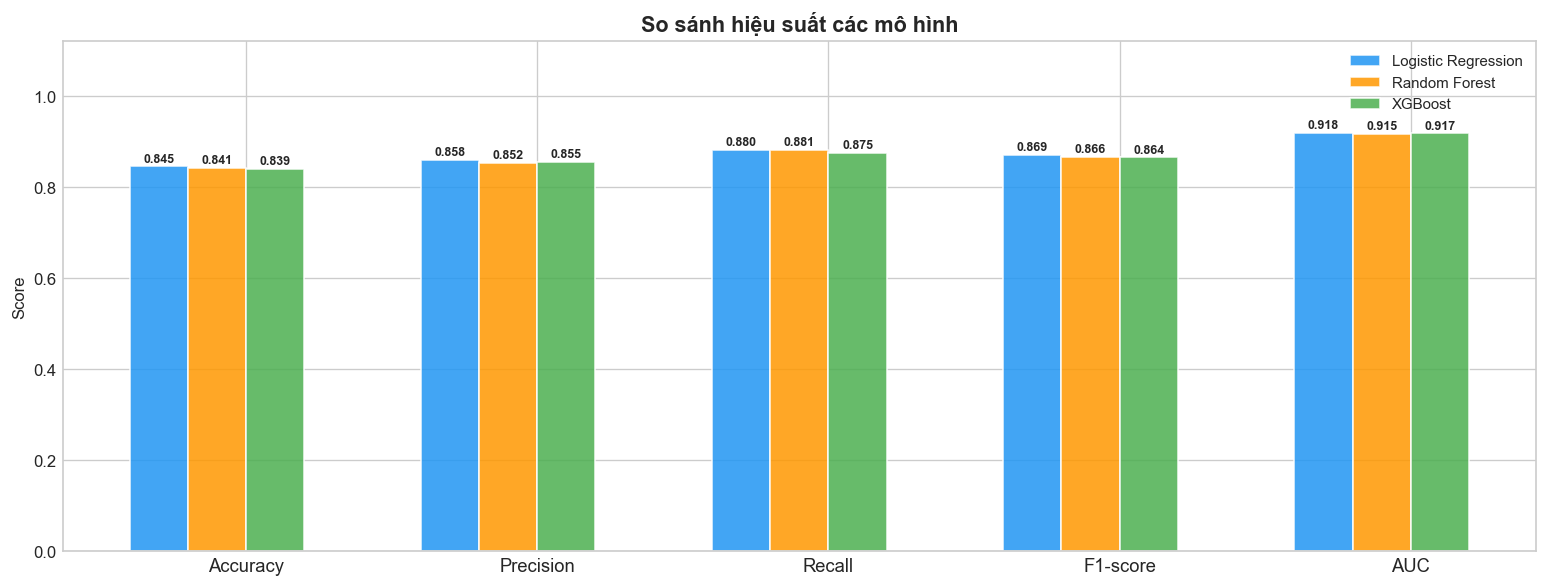

In [ ]:
bar_colors   = [COLORS['blue'], COLORS['orange'], COLORS['green'], COLORS['purple']]
show_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']
x, width     = np.arange(len(show_metrics)), 0.20

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, color) in enumerate(zip(results.keys(), bar_colors)):
    vals  = [results[name][m] for m in show_metrics]
    rects = ax.bar(x + i*width, vals, width, label=name,
                   color=color, alpha=0.85, edgecolor='white')
    for rect, v in zip(rects, vals):
        ax.text(rect.get_x()+rect.get_width()/2, rect.get_height()+0.004,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width*1.5); ax.set_xticklabels(show_metrics, fontsize=11)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('So sánh hiệu suất các mô hình', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()